## [friend]'s Structify interview:
Create a program that can *uniformly* generate (Cartesian coordinate) points on a circle with radius 1 centered at (0, 0).

### Solution 1: Circle inscribed in square
It's extremely easy to generate random points on a R^2 range (i.e. a rectangle). Generate random points on the square `[-1, 1] x [-1, 1]` that our circle is inscribed within and return a point if it's in the circle, discarding invalid points along the way.

### Solution 2: Generate random point from scratch
For generating random points on a rectangle, we can simply take the 2 defining facets (width and height) and generate random values for each to get our answer. It's not that simple with circles. We can define circle points by their angle and magnitude (the polar analog to cartesian coordinates when we talk about rectangles). The only problem is that if we use uniform random generation for the point's magnitude, we will get a non-uniform distribution.

Think about this - it's not like a inner ring that is 0.1 units thick should have the same number of points as an outer ring of the same thickness, but uniform generation for magnitude would yield that.

To uniformly generate points inside a circle, we need to ensure every location within the disk is equally likely to be chosen. If we simply select the radius $r$ uniformly from $[0, 1]$, we will end up with points that are clustered too densely near the center. The probability of landing within a thin ring at radius $r$ is proportional to the circumference of that ring, $2\pi r$, and the thickness, $dr$. So, the probability density is proportional to $2\pi r\, dr$. To find the correct way to sample $r$, we look at the cumulative distribution function (CDF):


$$
\text{CDF}(r) \propto \int_0^r 2\pi t\,dt = \pi r^2 \propto r^2 \quad\Rightarrow\quad r = \sqrt{u},\;\; u\sim U(0,1)
$$

Then $x = \sqrt{u}\cos\theta$, $y = \sqrt{u}\sin\theta$, where $u\sim U(0,1)$.

In [1]:
from random import uniform as rand
import numpy as np
PI = np.pi

# SOLUTION 1
def generate_circle_pt_from_square():
    while True:
        x = rand(-1, 1)
        y = rand(-1, 1)
        if x**2 + y**2 <= 1:
            return (x, y)

# SOLUTION 2
def generate_circle_pt_raw():
    theta = rand(0, 2 * PI)
    r = np.sqrt(rand(0, 1))
    y = r * np.sin(theta)
    x = r * np.cos(theta)
    return (x, y)


## Visual verification
This isn't a great way to confirm correctness, but we can visualize our solutions to see that the point distributions aren't chopped.

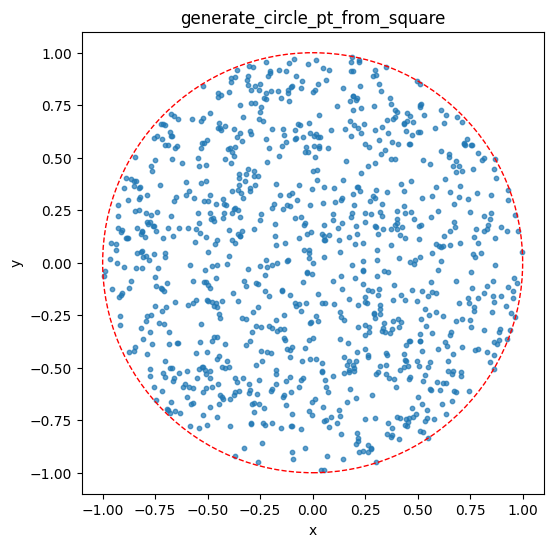

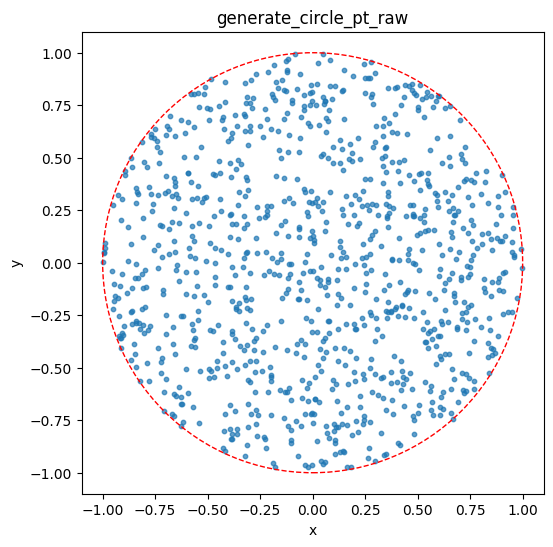

In [2]:
import matplotlib.pyplot as plt

def generate_points(gen_point_fn, n_points=1000):
    return [gen_point_fn() for _ in range(n_points)]

def plot_generated_points(gen_point_fn, n_points=1000):
    points = generate_points(gen_point_fn, n_points)
    xs, ys = zip(*points)

    plt.figure(figsize=(6,6))
    plt.scatter(xs, ys, s=10, alpha=0.7)
    plt.gca().set_aspect('equal')
    plt.title(gen_point_fn.__name__)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    circle = plt.Circle((0, 0), 1, color='r', fill=False, linestyle='--')
    plt.gca().add_artist(circle)
    plt.show()

# As we can see, both of our solutions look pretty uniform.
plot_generated_points(generate_circle_pt_from_square)
plot_generated_points(generate_circle_pt_raw)

## Verification using Monte Carlo simulation
Since we claim that our solutions are uniform distributions of a circle, we can try to take weird slices of our generated circles to estimate area ratios and see if they line up.

### I. Slices
Every even-sized slice of the circle (angle wise) should have an approximately equal number of points, obviously.
### II. Concentric circles
In a true uniform distribution, the point populations are proportional to area, so we should have a ratio of 1/4 when taking the total number of points vs the number of points in the inner circle with radius 1/2.

In [3]:
import math

# I. Slices
def slice_counts(points, n_slices):
    bins = [0] * n_slices
    for x, y in points:
        theta = math.atan2(y, x)
        i = int((theta + math.pi) / (2 * math.pi) * n_slices) % n_slices
        bins[i] += 1
    # Deviation stats (expected count per slice is uniform)
    n = len(points)
    expected = n / n_slices
    devs = [c - expected for c in bins]
    avg_pct = 100 * sum(abs(d) for d in devs) / n_slices / expected
    return bins, avg_pct

square_discard_points = generate_points(generate_circle_pt_from_square, 1000000)
raw_gen_points = generate_points(generate_circle_pt_raw, 1000000)
bins_sq, pct_sq = slice_counts(square_discard_points, 10)
bins_raw, pct_raw = slice_counts(raw_gen_points, 10)
print("square discard:", bins_sq, f"\nAvg deviation: {pct_sq:.2f}%")
print()
print("raw:", bins_raw, f"\nAvg deviation: {pct_raw:.2f}%")


square discard: [100024, 99968, 99660, 100272, 100134, 100016, 99789, 99897, 99832, 100408] 
Avg deviation: 0.17%

raw: [100242, 100438, 100160, 99707, 100097, 99720, 99797, 99615, 99846, 100378] 
Avg deviation: 0.26%


In [ ]:
# II. Concentric circles
def inner_ratio(points, r_inner=0.5):
    inside = sum(1 for x, y in points if x * x + y * y <= r_inner * r_inner)
    return inside / len(points)

square_discard_points = generate_points(generate_circle_pt_from_square, 1000000)
raw_gen_points = generate_points(generate_circle_pt_raw, 1000000)
square_discard_ratio = inner_ratio(square_discard_points, 0.5)
print(f"square discard: {square_discard_ratio} ≈ 0.25")
print(f"raw: {inner_ratio(raw_gen_points, 0.5)} ≈ 0.25")

square discard: 0.250278 ≈ 0.25
raw: 0.250364 ≈ 0.25
